In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 파일 이름 앞에 사진들이 들어있는 폴더명을 딱 붙여줍니다!
dog_img = cv2.imdecode(np.fromfile("juhwi practice/강아지.jpg", dtype=np.uint8), cv2.IMREAD_COLOR)
sand_img = cv2.imdecode(np.fromfile("juhwi practice/사막.jpg", dtype=np.uint8), cv2.IMREAD_COLOR)
selfie_img = cv2.imdecode(np.fromfile("juhwi practice/셀카.jpg", dtype=np.uint8), cv2.IMREAD_COLOR)

# 색상 변환
dog_img = cv2.cvtColor(dog_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)
selfie_img = cv2.cvtColor(selfie_img, cv2.COLOR_BGR2RGB)

# 크기 확인
print(dog_img.shape)
print(sand_img.shape)
print(selfie_img.shape)

(3088, 2316, 3)
(1920, 1440, 3)
(1932, 1932, 3)


In [21]:
model = deeplabv3_resnet101(pretrained=True).eval()
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
])

In [23]:
input_tensor = transform(dog_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    dog_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {dog_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [24]:
input_tensor = transform(selfie_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    selfie_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {selfie_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [26]:
dog_predictions_resized = cv2.resize(dog_predictions, (dog_img.shape[1], dog_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {dog_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (3088, 2316)


In [27]:
selfie_predictions_resized = cv2.resize(selfie_predictions, (selfie_img.shape[1], selfie_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {selfie_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (1932, 1932)


In [28]:
unique_classes = np.unique(dog_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [ 0  8 12 15]


In [29]:
unique_classes = np.unique(selfie_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [ 0 15]


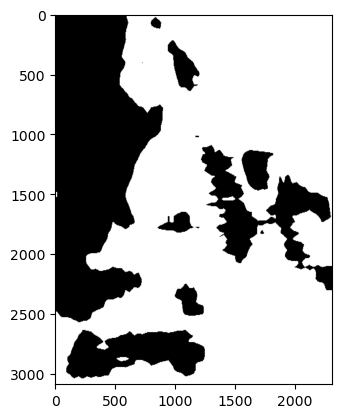

In [38]:
seg_map = (dog_predictions_resized == 0) | (dog_predictions_resized == 8)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

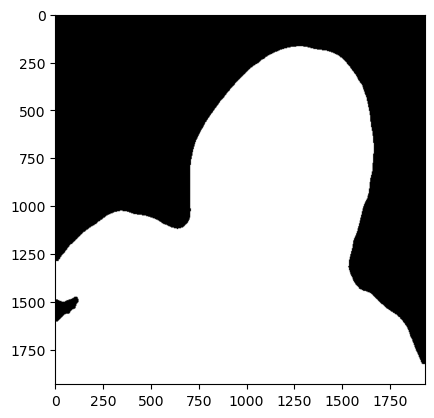

In [34]:
target_class_id = 15

seg_map = (selfie_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

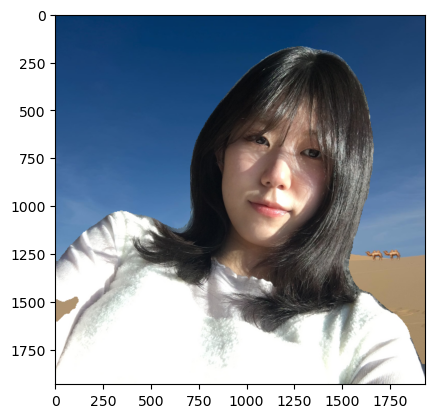

In [41]:
# 셀카 합성 직전에는 셀카용 마스크(selfie_predictions_resized)로 확실하게 지정!
seg_map = (selfie_predictions_resized == 15)
img_mask = seg_map.astype(np.uint8) * 255

# 1. 배경을 셀카 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (selfie_img.shape[1], selfie_img.shape[0]))

# 2. 셀카 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, selfie_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

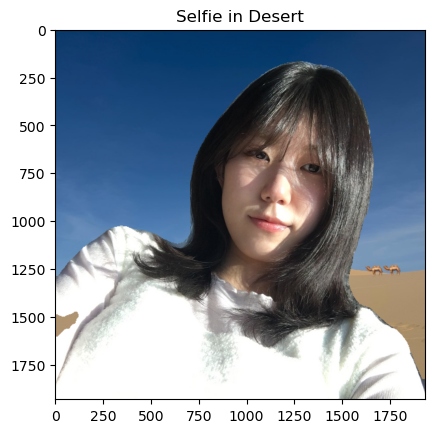

🎉 드디어 성공! 'juhwi practice/사막셀카.jpg' 파일이 새로 저장되었습니다.


In [48]:
# 1. 셀카 마스크 확실하게 다시 잡아주기 (사람 = 15)
seg_map = (selfie_predictions_resized == 15)
img_mask = seg_map.astype(np.uint8) * 255

# 2. 사막 배경을 셀카 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (selfie_img.shape[1], selfie_img.shape[0]))

# 3. 셀카 부분만 남기고 배경 적용 (여기서 result_img가 '셀카'로 업데이트 됩니다!)
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
result_img = np.where(img_mask_color == 255, selfie_img, sand_img_resized)

# 4. 화면에 셀카 합성 잘 되었는지 먼저 보여주기
plt.imshow(result_img)
plt.title("Selfie in Desert")
plt.show()

# 5. [저장 단계] RGB를 BGR로 변환 후 '사막셀카.jpg'로 저장하기
result_img_bgr = cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR)
save_path = "juhwi practice/사막셀카.jpg"
success = cv2.imwrite(save_path, result_img_bgr)

# 6. 저장 성공 확인 메시지
if success:
    print(f"🎉 드디어 성공! '{save_path}' 파일이 새로 저장되었습니다.")
else:
    print("😭 저장 실패! 경로를 다시 확인해주세요.")

In [50]:
cd ~/AIFFEL_quest_cr/juhwi\ practice/

[Errno 2] No such file or directory: '/home/jovyan/AIFFEL_quest_cr/juhwi practice/'
/home/jovyan/work/AIFFEL_quest_cr


In [ ]:
# 인물 모드 합성 문제

## 문제점
* **강아지 사진:** 하얀색 강아지 털과 흰 옷의 색상 동질화로 인해 강아지 얼굴 영역이 `0`(배경)으로 잘못 인식되어 누락
* **셀카 사진:** 하얀 옷의 빛 반사(Hilight)로 인해 팔 부분이 배경으로 인식되어 잘려 나가는 현상


## 제안
- **CRF(Conditional Random Field) 후처리를 통해 픽셀 간의 경계면을 정밀하게 추출하여 마스크 오차 보완.
- **ToF 센서를 이용한 Depth Map 융합으로 색상과 무관한 물리적 거리 기반 객체 분리